# **Análisis Exploratorio de Datos - Lung Cancer Prediction (Kaggle)**

In [ ]:
# Dataset: https://www.kaggle.com/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link/data

Dataset: https://www.kaggle.com/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link/data

## **1. Importando Librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from warnings import filterwarnings
# filterwarnings('ignore')

## **2. Análisis Univariante**

In [2]:
file = "/content/lung-cancer-patient-dataset.csv"
data = pd.read_csv(file)
data.columns = data.columns.str.strip()
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data.drop(columns = ['index', 'patient_id'], inplace = True)
data.head()

,age,gender,air_pollution,alcohol_use,dust_allergy,occupational_hazards,genetic_risk,chronic_lung_disease,balanced_diet,obesity,...,fatigue,weight_loss,shortness_of_breath,wheezing,swallowing_difficulty,clubbing_of_finger_nails,frequent_cold,dry_cough,snoring,level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


In [ ]:
data.dtypes

age                          int64
gender                       int64
air_pollution                int64
alcohol_use                  int64
dust_allergy                 int64
occupational_hazards         int64
genetic_risk                 int64
chronic_lung_disease         int64
balanced_diet                int64
obesity                      int64
smoking                      int64
passive_smoker               int64
chest_pain                   int64
coughing_of_blood            int64
fatigue                      int64
weight_loss                  int64
shortness_of_breath          int64
wheezing                     int64
swallowing_difficulty        int64
clubbing_of_finger_nails     int64
frequent_cold                int64
dry_cough                    int64
snoring                      int64
level                       object
dtype: object

In [ ]:
data.dtypes.value_counts()

int64     23
object     1
dtype: int64

In [ ]:
data.select_dtypes(include=['int64']).nunique()

age                         40
gender                       2
air_pollution                8
alcohol_use                  8
dust_allergy                 8
occupational_hazards         8
genetic_risk                 7
chronic_lung_disease         7
balanced_diet                7
obesity                      7
smoking                      8
passive_smoker               8
chest_pain                   9
coughing_of_blood            9
fatigue                      8
weight_loss                  8
shortness_of_breath          8
wheezing                     8
swallowing_difficulty        8
clubbing_of_finger_nails     9
frequent_cold                7
dry_cough                    7
snoring                      7
dtype: int64

In [ ]:
data.isnull().values.any()

False

In [3]:
data.duplicated().sum()

848

In [4]:
data = data.drop_duplicates()
data.shape

(152, 24)

In [ ]:
data.describe().loc[['min','max']]

,age,gender,air_pollution,alcohol_use,dust_allergy,occupational_hazards,genetic_risk,chronic_lung_disease,balanced_diet,obesity,...,coughing_of_blood,fatigue,weight_loss,shortness_of_breath,wheezing,swallowing_difficulty,clubbing_of_finger_nails,frequent_cold,dry_cough,snoring
min,14.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
max,73.0,2.0,8.0,8.0,8.0,8.0,7.0,7.0,7.0,7.0,...,9.0,9.0,8.0,9.0,8.0,8.0,9.0,7.0,7.0,7.0


In [ ]:
group_target = data.groupby('level')["age"].count() / len(data) * 100

In [ ]:
# Medianamente balanceado ...
group_target

level
High      34.868421
Low       30.921053
Medium    34.210526
Name: age, dtype: float64

In [ ]:
gender_target = data.groupby('gender')['age'].count() / len(data) * 100

In [ ]:
gender_target

gender
1    58.552632
2    41.447368
Name: age, dtype: float64

In [ ]:
# Variables numericas
numerical = data.select_dtypes(include = "number").columns.tolist()

In [ ]:
numerical

['age',
 'gender',
 'air_pollution',
 'alcohol_use',
 'dust_allergy',
 'occupational_hazards',
 'genetic_risk',
 'chronic_lung_disease',
 'balanced_diet',
 'obesity',
 'smoking',
 'passive_smoker',
 'chest_pain',
 'coughing_of_blood',
 'fatigue',
 'weight_loss',
 'shortness_of_breath',
 'wheezing',
 'swallowing_difficulty',
 'clubbing_of_finger_nails',
 'frequent_cold',
 'dry_cough',
 'snoring']

In [ ]:
# Variables categoricas
categorical = data.select_dtypes(exclude = "number").columns.tolist()

In [ ]:
categorical

['level']

In [ ]:
!pip install fitter
from fitter import Fitter, get_common_distributions, get_distributions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 75.0 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.1
    Uninstalling matplotlib-3.7.1:
      Successfully uninstalled matplotlib-3.7.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lida 0.0.10 requires fastapi, which is not installed.
lida 0.0.10 requires kaleido, which is not installed.
lida 0.0.10 requires python-multipart, which is not installed.
lida 0.0.10 requires uvicorn, which is not installed.


2024-01-06 20:53:48.612 | INFO     | fitter.fitter:_fit_single_distribution:337 - Fitted lognorm distribution with error=0.068908)
2024-01-06 20:53:48.681 | INFO     | fitter.fitter:_fit_single_distribution:337 - Fitted gamma distribution with error=0.06888)
2024-01-06 20:53:48.790 | INFO     | fitter.fitter:_fit_single_distribution:337 - Fitted beta distribution with error=0.068872)
2024-01-06 20:53:48.813 | INFO     | fitter.fitter:_fit_single_distribution:337 - Fitted norm distribution with error=0.069508)
2024-01-06 20:53:49.373 | INFO     | fitter.fitter:_fit_single_distribution:337 - Fitted burr distribution with error=0.069226)


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.068872,896.925779,909.021301,inf,0.070917,0.410147
gamma,0.068880,899.518052,908.589694,inf,0.068627,0.451327
lognorm,0.068908,900.812974,909.884615,inf,0.069389,0.437376
burr,0.069226,907.148218,919.243740,inf,0.076694,0.316704
norm,0.069508,910.501243,916.549004,inf,0.100140,0.088505


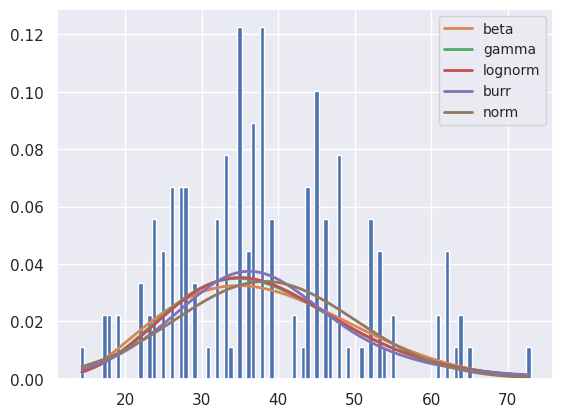

In [ ]:
fit = data[data.columns[0]].values

f = Fitter(fit,distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
           #distributions= get_common_distributions())
f.fit()
f.summary()

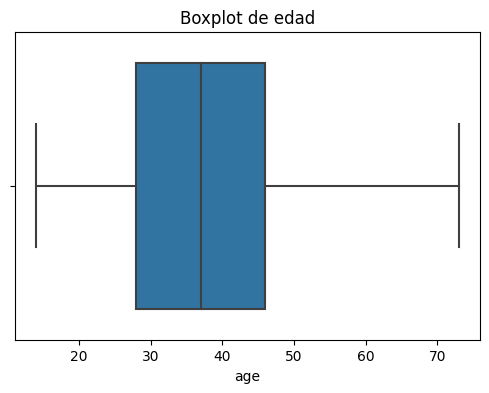

In [ ]:
plt.figure(figsize = (6,4))
sns.boxplot(x=data["age"])
plt.title("Boxplot de edad", fontsize = 12)
plt.show()

In [ ]:
bp = pd.DataFrame.boxplot(data["age"], return_type='dict')
whiskers = [whiskers.get_ydata() for whiskers in bp["whiskers"]]
print(data[data.columns[0]].describe())
print("lower whiskers: "+str(whiskers[0]))
print("upper whiskers: "+str(whiskers[1]))
plt.close()

count    152.000000
mean      38.236842
std       11.798382
min       14.000000
25%       28.000000
50%       37.000000
75%       46.000000
max       73.000000
Name: age, dtype: float64
lower whiskers: [28. 14.]
upper whiskers: [46. 73.]


In [ ]:
def numerical_analisis(data, nums, opt = True):
  for num in nums:
    print(" " * 20, "Histograma", " " * 20)
    data[num].plot.hist(bins = 25, figsize = (8, 4))
    plt.title(f'{num}\n', fontdict = {'fontsize' : 14})
    plt.show()
    print("\n")
    if opt:
      print(" " * 20, "Boxplot", " " * 20)
      data[num].plot.box(figsize = (8, 4))
      plt.show()
      print("\n")

In [ ]:
numerical_analisis(data[numerical], numerical)

In [ ]:
data[numerical].describe()

,age,gender,air_pollution,alcohol_use,dust_allergy,occupational_hazards,genetic_risk,chronic_lung_disease,balanced_diet,obesity,...,coughing_of_blood,fatigue,weight_loss,shortness_of_breath,wheezing,swallowing_difficulty,clubbing_of_finger_nails,frequent_cold,dry_cough,snoring
count,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,...,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000
mean,38.236842,1.414474,3.717105,4.480263,5.046053,4.710526,4.486842,4.243421,4.427632,4.414474,...,4.796053,3.763158,3.828947,4.269737,3.776316,3.750000,3.894737,3.480263,3.684211,2.921053
std,11.798382,0.494259,1.978084,2.601503,2.027424,2.158095,2.143794,1.880527,2.151857,2.120365,...,2.453107,2.230840,2.233924,2.263943,2.036740,2.196475,2.344948,1.848466,2.047195,1.542022
min,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,28.000000,1.000000,2.000000,2.000000,3.750000,3.000000,2.000000,3.000000,2.000000,3.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,37.000000,1.000000,3.000000,5.000000,6.000000,5.000000,5.000000,4.000000,4.000000,4.000000,...,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000
75%,46.000000,2.000000,6.000000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,7.000000,...,7.000000,5.000000,6.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000
max,73.000000,2.000000,8.000000,8.000000,8.000000,8.000000,7.000000,7.000000,7.000000,7.000000,...,9.000000,9.000000,8.000000,9.000000,8.000000,8.000000,9.000000,7.000000,7.000000,7.000000


In [ ]:
numerical

['age',
 'gender',
 'air_pollution',
 'alcohol_use',
 'dust_allergy',
 'occupational_hazards',
 'genetic_risk',
 'chronic_lung_disease',
 'balanced_diet',
 'obesity',
 'smoking',
 'passive_smoker',
 'chest_pain',
 'coughing_of_blood',
 'fatigue',
 'weight_loss',
 'shortness_of_breath',
 'wheezing',
 'swallowing_difficulty',
 'clubbing_of_finger_nails',
 'frequent_cold',
 'dry_cough',
 'snoring']

In [ ]:
# Con respecto a la variable objetivo 'level'
def objetive_analisis(data, obj, vars):
  f, axes = plt.subplots(nrows = 8, ncols = 3, figsize = (30, 25))
  print(' ' * 20 + 'Boxplot' + ' ' * 20)
  col, row = 0, 0
  for var in vars:
    sns.boxplot(x = obj, y = var, data = data, ax = axes[row, col])
    col = col + 1
    if (col == 3):
      col = 0
      row = row + 1

In [ ]:
objetive_analisis(data, 'Level', numerical)

## **Conclusiones sobre el Análisis Univariante**

En general se trata de un dataset de registros médicos de personas para poder categorizarlas como un riesgo bajo, medio y alto de sufrir cáncer de pulmón. Todas las variables son de tipo numérico y la única categórica es la variable target 'Level' que nos divide a la población en los niveles de riesgo.

Existen valores duplicados, pero los voy a ignorar porque pueden ser casos similares, tal vez esto se pueda revisar previamente eliminar la columna patient_id. Así mismo el dataset está medianamente balanceado en cuanto a categorías de riesgo en pacientes.

**a. Univariante**

- **Edad:** Se realizo la encuesta o formulario a personas desde 14 años hasta 73 años, siendo el promedio 37 años.

- **Genero:** Entre hombres y mujeres, en el dataset no se especifica qué número representa a hombres o mujeres. Algunos sugieren '1' para hombres y '2' para mujeres. En todo caso tenemos 59.8% del género '1' y 40.2 del género '2'.

- **Contaminación del Aire:** Nivel de contaminación en el ambiente donde vive el paciente. Medido de una escala de 1 a 8, no se especifica el orden pero supongamos que 1 es limpio y 8 muy contaminado. Por ahora sabemos que la media es de 3.84.

- **Consumo de Alcohol:** Frecuencia de uso o consumo de alcohol, medido en una escala también del 1 al 8. La media es 4.56, no se especifica si es, por ejemplo, latas o presentaciones al día o mes.

- **Alergía (Polvo):** Medido de una escala del 1 al 8 también, la media es 5.16. Tampoco se especifica la métrica.

- **Riesgo Ocupacional:** Exposición a contaminantes o situaciones de riesgo del paciente, medido de una escala del 1 al 8. La media es de 4.84 y no presenta métrica.

- **Predisposición Genética:** Historial y familiares, tenemos la medida desde un valor inicial de 1 hasta 7. La media es de 4.58 y no se detalla la métrica.

- **Problemas Respiratorios:** Enfermadades relacionadas, medida del 1 al 7 siendo la media 4.38. Sin métrica definida.

- **Dieta Balanceada:** Hábitos alimenticios del paciente, varia desde el valor de 1 al 7, no se especifica la métrica pero la media es 4.49.

- **Obesidad:** Situación y relación peso / estatura probablemente (IMC). Se mide desde 1 al 7 y tenemos una media de 4.47. No hay métrica.

- **Fumador:** Frecuencia de consumo de cigarros del paciente. Tenemos una métrica desde el 1 al 8. Media de 3.94 y sin métrica vista.


## **Analisis Multivariable**

In [ ]:
def correlational_analisis(data, target, numerical):
  df_num = data[numerical + [target]].copy()
  df_num = pd.get_dummies(df_num, columns = [target], drop_first = False)
  display(df_num.sample(5))
  plt.figure(figsize = (20, 10))
  mask = np.triu(np.ones_like(df_num.corr(), dtype = np.bool))
  sns.heatmap(round(df_num.corr(), 2), mask = mask, cmap = "BrBG", annot = True, vmin = -1, vmax = 1)
  plt.show()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level_High,Level_Low,Level_Medium
424,63,1,6,8,7,7,6,7,7,3,...,5,2,3,2,1,7,6,1,0,0
873,37,1,6,7,7,7,7,7,6,7,...,7,6,7,8,7,6,2,1,0,0
613,44,1,2,3,2,1,3,2,1,2,...,3,2,1,2,3,2,3,0,1,0
427,37,1,6,7,7,7,7,6,7,7,...,6,7,6,7,2,3,1,1,0,0
286,38,2,6,8,7,7,7,6,2,4,...,6,5,1,9,3,4,2,0,0,1


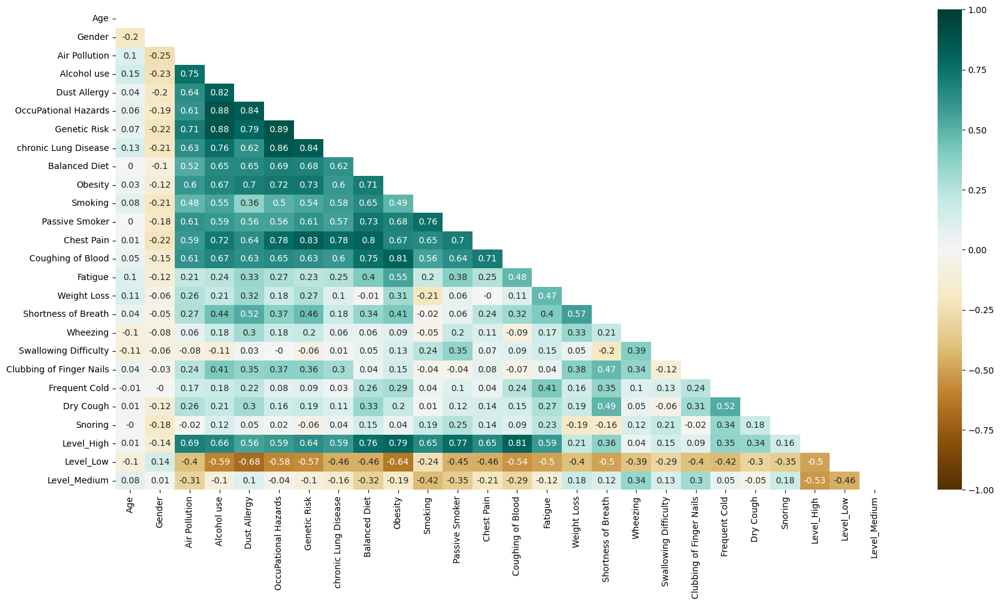

In [ ]:
correlational_analisis(data, 'Level', numerical)

In [ ]:
target_count[0]

53

### Edad

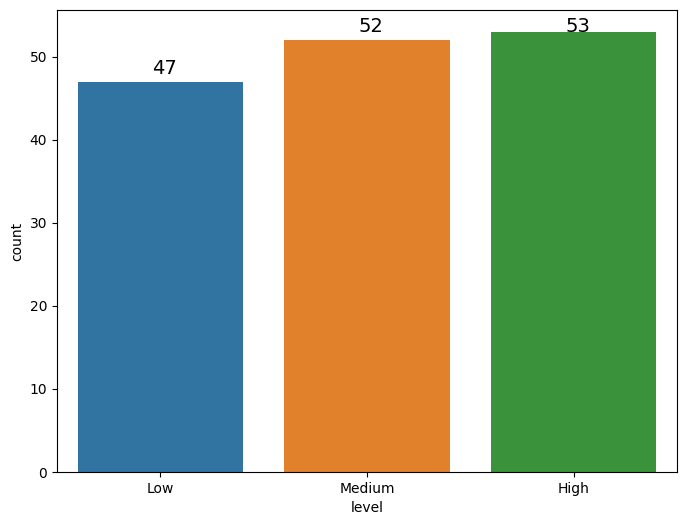

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x=data['level'])
target_count = data.level.value_counts()
plt.annotate(text=str(target_count[0]), xy=(1.96,target_count[0]), size=14)
plt.annotate(text=str(target_count[1]), xy=(0.96,1+target_count[1]), size=14)
plt.annotate(text=str(target_count[2]), xy=(-0.04,1+target_count[2]), size=14)
plt.show()

In [ ]:
numerical

['age',
 'gender',
 'air_pollution',
 'alcohol_use',
 'dust_allergy',
 'occupational_hazards',
 'genetic_risk',
 'chronic_lung_disease',
 'balanced_diet',
 'obesity',
 'smoking',
 'passive_smoker',
 'chest_pain',
 'coughing_of_blood',
 'fatigue',
 'weight_loss',
 'shortness_of_breath',
 'wheezing',
 'swallowing_difficulty',
 'clubbing_of_finger_nails',
 'frequent_cold',
 'dry_cough',
 'snoring']

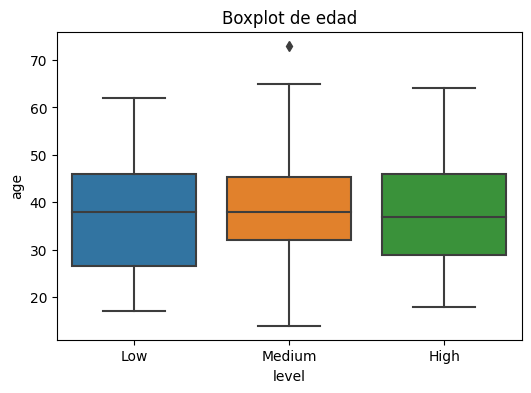

In [ ]:
plt.figure(figsize = (6,4))
sns.boxplot(x=data["level"],y=data["age"])
plt.title("Boxplot de edad", fontsize = 12)
plt.show()

Text(0.5, 1.0, 'Gráfico de Violín del Cancer de Pulmon respecto la Edad')

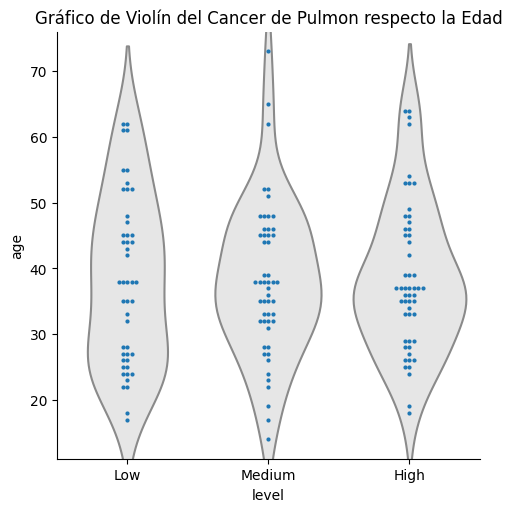

In [ ]:
sns.catplot(data=data, x="level", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="level", y="age", size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto la Edad')

In [ ]:
print(data.groupby(by=["level","age"]).size())

level   age
High    18     1
        19     1
        24     1
        25     2
        26     3
              ..
Medium  51     1
        52     2
        62     1
        65     1
        73     1
Length: 76, dtype: int64


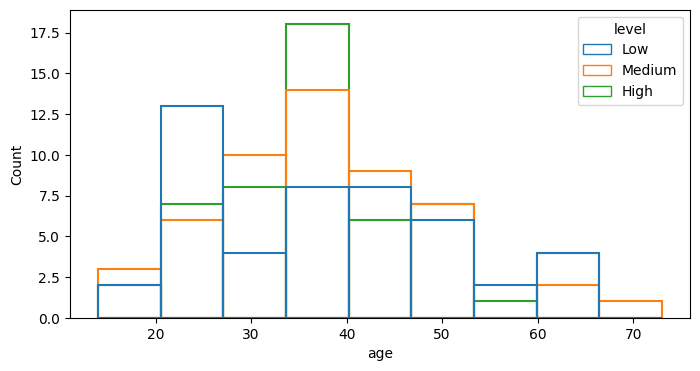

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=data,x='age',hue="level",kde=False,fill=False,color='white')
plt.show()

gender,1,2
level,,
High,38,15
Low,20,27
Medium,31,21


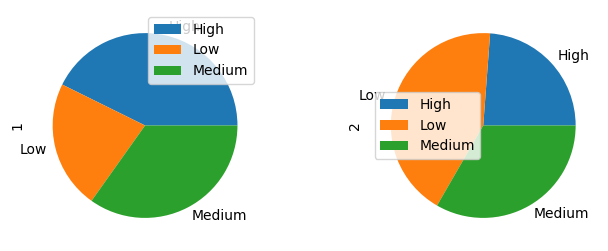

In [ ]:
pie_data = data.groupby(by=["gender","level"]).size().unstack(fill_value=0,level=0)
pie_data.plot.pie(subplots=True,figsize=(8, 3))
data.groupby(by=["gender","level"]).size().unstack(fill_value=0,level=0)

* Columnas para clasificar: 'age','gender'
* Columnas de habitos: 'alcohol_use','balanced_diet','obesity','smoking', 'passive_smoker',
* Columnas de sintomas: 'chest_pain',
 'coughing_of_blood',
 'fatigue',
 'weight_loss',
 'shortness_of_breath',
 'wheezing',
 'swallowing_difficulty',
 'clubbing_of_finger_nails',
 'frequent_cold',
 'dry_cough',
 'snoring'
* Columnas de ambiente: 'air_pollution'


### Columnas de habitos



level   smoking
High    2          11
        4           2
        6           2
        7          26
        8          12
Low     1           9
        2          11
        3          10
        4           7
        6           6
        7           4
Medium  1          17
        2          12
        3          16
        5           2
        6           4
        8           1
dtype: int64

<Figure size 900x900 with 0 Axes>

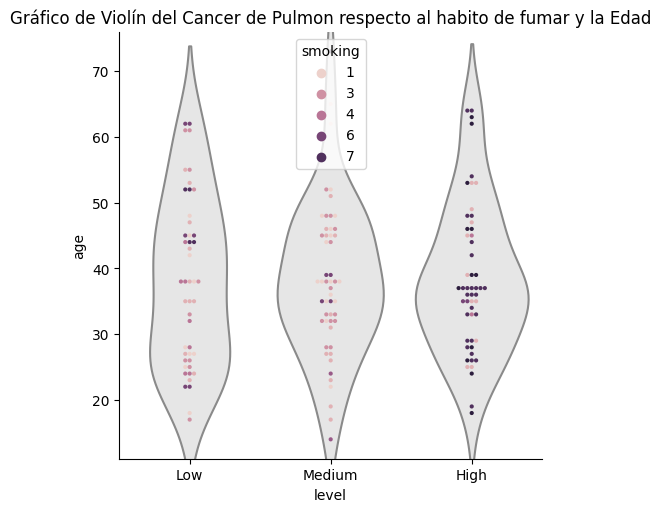

In [ ]:
plt.figure(figsize = (9,9))
sns.catplot(data=data, x="level", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="level", y="age", hue='smoking', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto al habito de fumar y la Edad')
data.groupby(by=["level","smoking"]).size()

gender  level   smoking
1       High    2           7
                4           2
                6           1
                7          20
                8           8
        Low     1           4
                2           3
                3           4
                4           4
                6           3
                7           2
        Medium  1          11
                2           8
                3           7
                5           2
                6           2
                8           1
2       High    2           4
                6           1
                7           6
                8           4
        Low     1           5
                2           8
                3           6
                4           3
                6           3
                7           2
        Medium  1           6
                2           4
                3           9
                6           2
dtype: int64

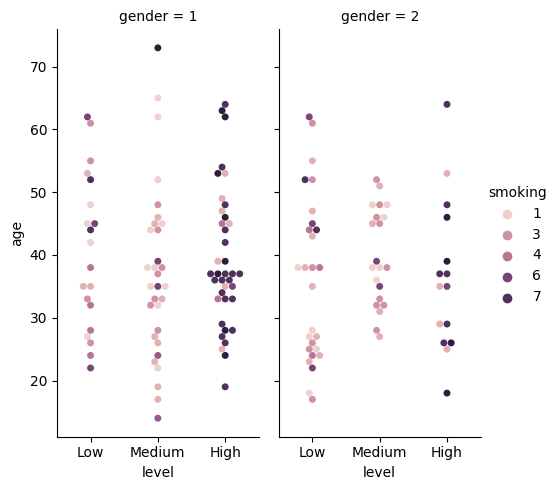

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="level", y="age", hue="smoking", col="gender",
    aspect=.5
)
data.groupby(by=["gender","level","smoking"]).size()

level   alcohol_use
High    4               1
        5              11
        6               2
        7              21
        8              18
Low     1              14
        2              19
        3              11
        4               2
        7               1
Medium  1               8
        2              14
        3               3
        4               2
        5               4
        6              11
        8              10
dtype: int64

<Figure size 900x900 with 0 Axes>

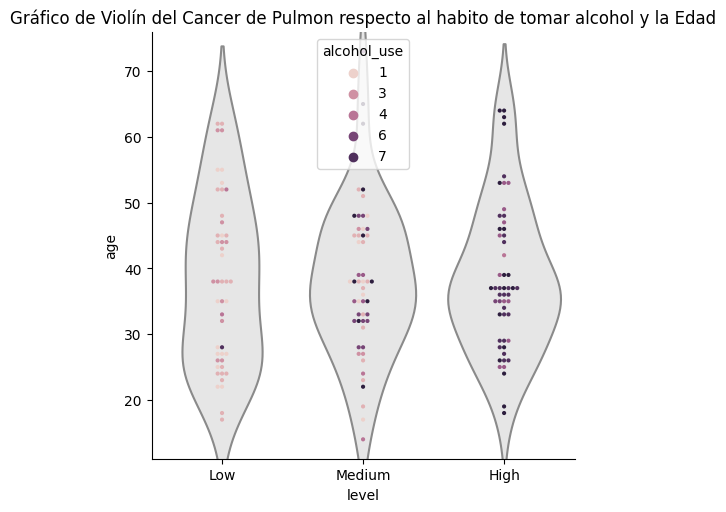

In [ ]:
plt.figure(figsize = (9,9))
sns.catplot(data=data, x="level", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="level", y="age", hue='alcohol_use', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto al habito de tomar alcohol y la Edad')
data.groupby(by=["level","alcohol_use"]).size()

gender  level   alcohol_use
1       High    4               1
                5               7
                6               1
                7              17
                8              12
        Low     1               7
                2               5
                3               6
                4               1
                7               1
        Medium  1               4
                2               8
                3               2
                4               2
                5               2
                6               5
                8               8
2       High    5               4
                6               1
                7               4
                8               6
        Low     1               7
                2              14
                3               5
                4               1
        Medium  1               4
                2               6
                3               1
                5   

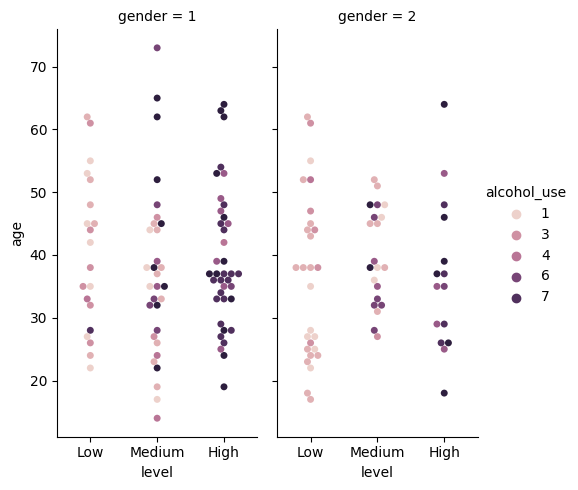

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="level", y="age", hue="alcohol_use", col="gender",
    aspect=.5
)
data.groupby(by=["gender","level","alcohol_use"]).size()

level   balanced_diet
High    4                 1
        6                16
        7                36
Low     1                 9
        2                14
        3                11
        4                 6
        5                 5
        7                 2
Medium  2                18
        3                17
        4                 2
        5                 2
        6                 8
        7                 5
dtype: int64

<Figure size 900x900 with 0 Axes>

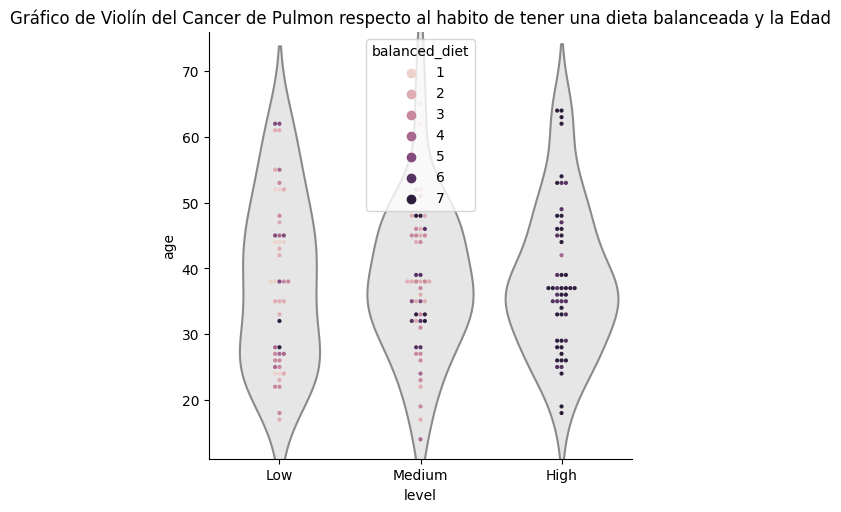

In [ ]:
plt.figure(figsize = (9,9))
sns.catplot(data=data, x="level", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="level", y="age", hue='balanced_diet', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto al habito de tener una dieta balanceada y la Edad')
data.groupby(by=["level","balanced_diet"]).size()

gender  level   balanced_diet
1       High    4                 1
                6                11
                7                26
        Low     1                 4
                2                 5
                3                 4
                4                 3
                5                 2
                7                 2
        Medium  2                12
                3                10
                4                 2
                5                 1
                6                 4
                7                 2
2       High    6                 5
                7                10
        Low     1                 5
                2                 9
                3                 7
                4                 3
                5                 3
        Medium  2                 6
                3                 7
                5                 1
                6                 4
                7                 

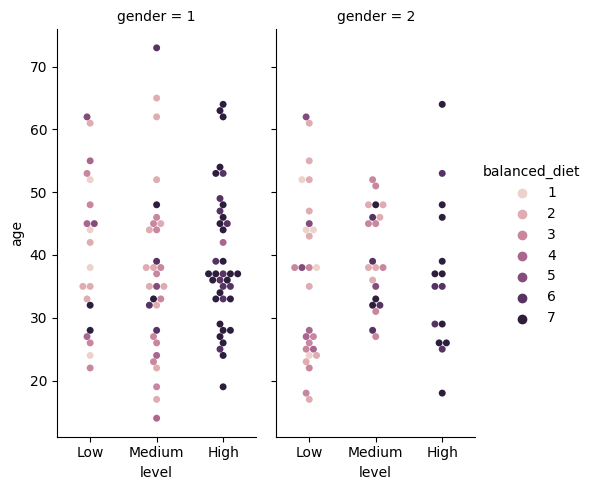

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="level", y="age", hue="balanced_diet", col="gender",
    aspect=.5
)
data.groupby(by=["gender","level","balanced_diet"]).size()

level   obesity
High    3           3
        4           2
        6           1
        7          47
Low     1          11
        2          15
        3          11
        4          10
Medium  2           6
        3          17
        4          17
        5           3
        6           4
        7           5
dtype: int64

<Figure size 900x900 with 0 Axes>

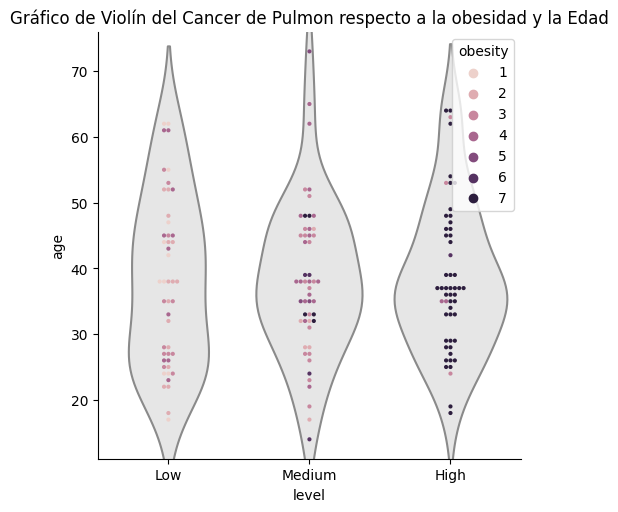

In [ ]:
plt.figure(figsize = (9,9))
sns.catplot(data=data, x="level", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="level", y="age", hue='obesity', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto a la obesidad y la Edad')
data.groupby(by=["level","obesity"]).size()

gender  level   obesity
1       High    3           3
                4           1
                6           1
                7          33
        Low     1           5
                2           7
                3           4
                4           4
        Medium  2           3
                3          10
                4          11
                5           2
                6           3
                7           2
2       High    4           1
                7          14
        Low     1           6
                2           8
                3           7
                4           6
        Medium  2           3
                3           7
                4           6
                5           1
                6           1
                7           3
dtype: int64

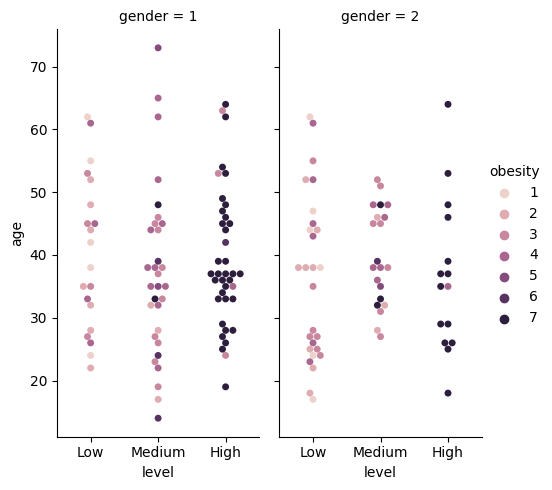

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="level", y="age", hue="obesity", col="gender",
    aspect=.5
)
data.groupby(by=["gender","level","obesity"]).size()

level   passive_smoker
High    3                 11
        7                 27
        8                 15
Low     1                  8
        2                 19
        3                  4
        4                 12
        5                  2
        6                  2
Medium  2                 24
        3                  8
        4                 15
        5                  1
        6                  4
dtype: int64

<Figure size 900x900 with 0 Axes>

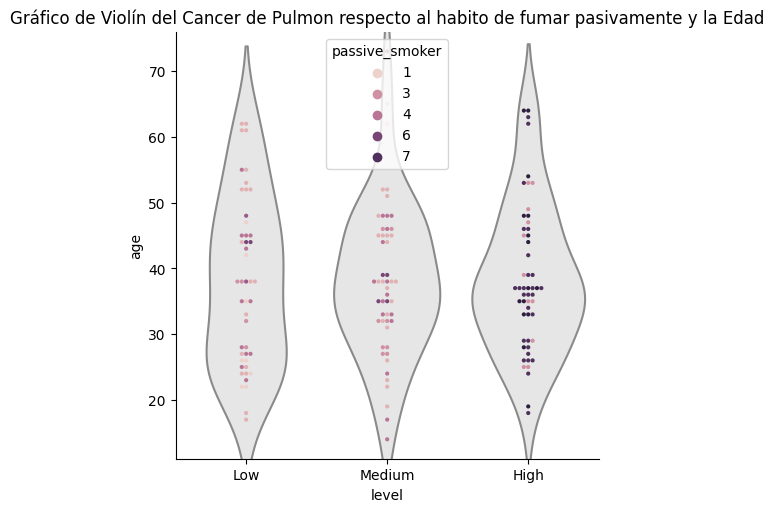

In [ ]:
plt.figure(figsize = (9,9))
sns.catplot(data=data, x="level", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="level", y="age", hue='passive_smoker', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto al habito de fumar pasivamente y la Edad')
data.groupby(by=["level","passive_smoker"]).size()

gender  level   passive_smoker
1       High    3                  7
                7                 20
                8                 11
        Low     1                  4
                2                  7
                3                  3
                4                  4
                5                  1
                6                  1
        Medium  2                 16
                3                  4
                4                  8
                5                  1
                6                  2
2       High    3                  4
                7                  7
                8                  4
        Low     1                  4
                2                 12
                3                  1
                4                  8
                5                  1
                6                  1
        Medium  2                  8
                3                  4
                4                  7
       

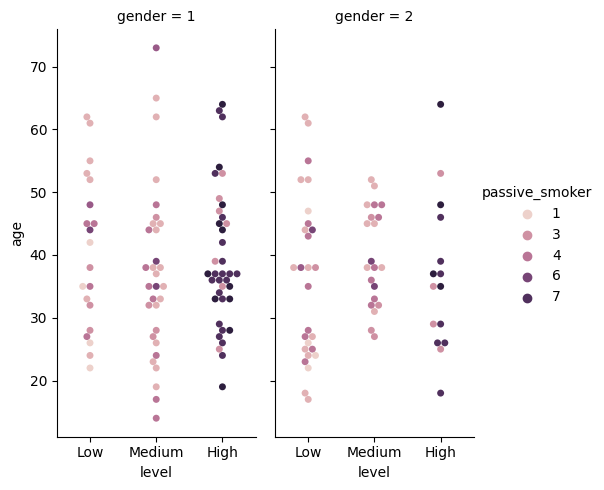

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="level", y="age", hue="passive_smoker", col="gender",
    aspect=.5
)
data.groupby(by=["gender","level","passive_smoker"]).size()

### Columnas de ambiente

level   air_pollution
High    2                 3
        4                 9
        6                35
        7                 4
        8                 2
Low     1                 5
        2                18
        3                19
        4                 3
        5                 1
        6                 1
Medium  1                16
        2                12
        3                 9
        4                 4
        5                 1
        6                10
dtype: int64

<Figure size 900x900 with 0 Axes>

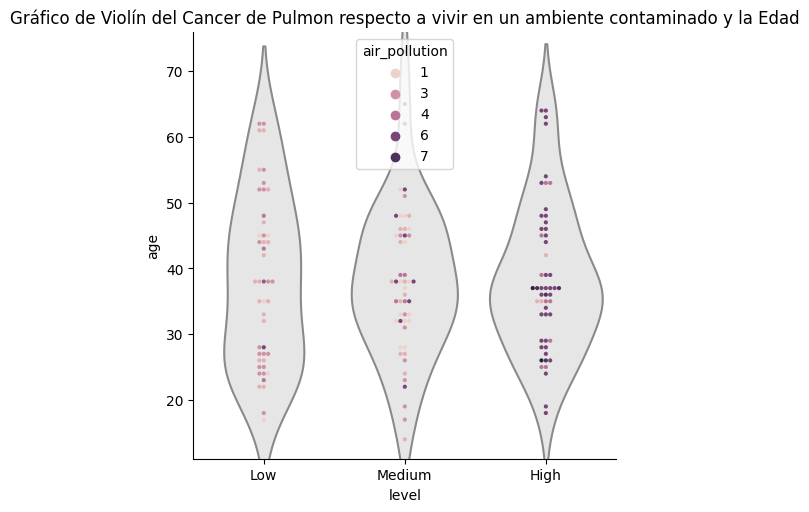

In [ ]:
plt.figure(figsize = (9,9))
sns.catplot(data=data, x="level", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="level", y="age", hue='air_pollution', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto a vivir en un ambiente contaminado y la Edad')
data.groupby(by=["level","air_pollution"]).size()

gender  level   air_pollution
1       High    2                 2
                4                 5
                6                28
                7                 2
                8                 1
        Low     1                 2
                2                 9
                3                 7
                4                 1
                6                 1
        Medium  1                 7
                2                 7
                3                 6
                4                 2
                5                 1
                6                 8
2       High    2                 1
                4                 4
                6                 7
                7                 2
                8                 1
        Low     1                 3
                2                 9
                3                12
                4                 2
                5                 1
        Medium  1                 

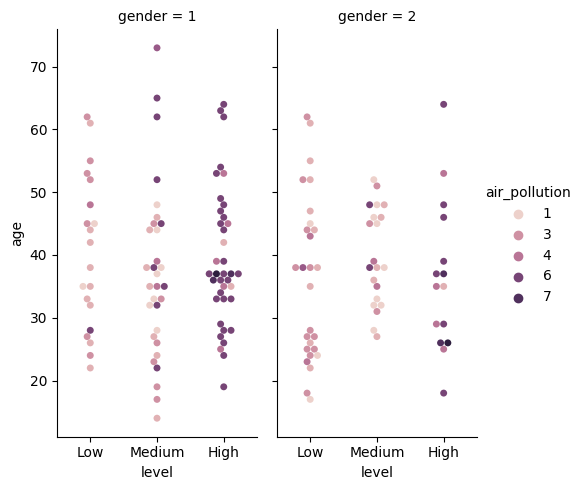

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="level", y="age", hue="air_pollution", col="gender",
    aspect=.5
)
data.groupby(by=["gender","level","air_pollution"]).size()

level   occupational_hazards
High    3                        2
        5                       11
        6                        1
        7                       39
Low     1                       10
        2                       11
        3                       12
        4                       10
        5                        2
        7                        2
Medium  2                       11
        3                        8
        4                        6
        5                        8
        6                        4
        7                       10
        8                        5
dtype: int64

<Figure size 900x900 with 0 Axes>

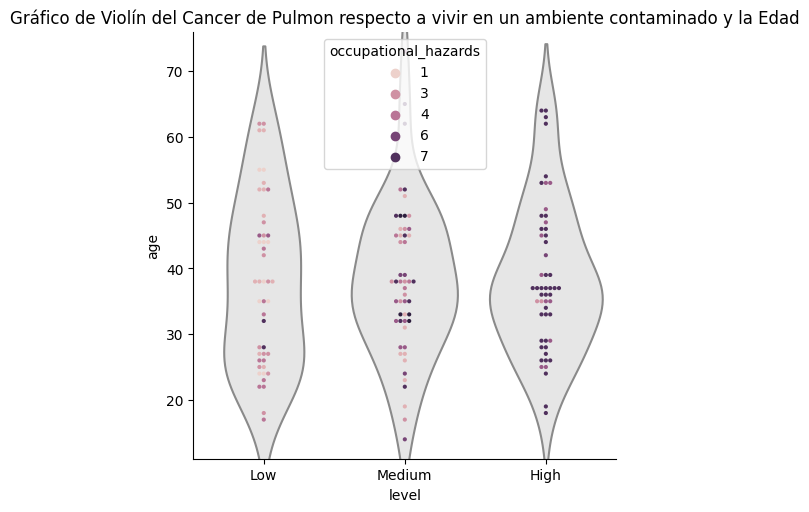

In [5]:
plt.figure(figsize = (9,9))
sns.catplot(data=data, x="level", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="level", y="age", hue='occupational_hazards', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto a vivir en un ambiente contaminado y la Edad')
data.groupby(by=["level","occupational_hazards"]).size()

gender  level   occupational_hazards
1       High    3                        1
                5                        7
                6                        1
                7                       29
        Low     1                        4
                2                        5
                3                        4
                4                        4
                5                        1
                7                        2
        Medium  2                        7
                3                        4
                4                        3
                5                        4
                6                        3
                7                        8
                8                        2
2       High    3                        1
                5                        4
                7                       10
        Low     1                        6
                2                        6
                3

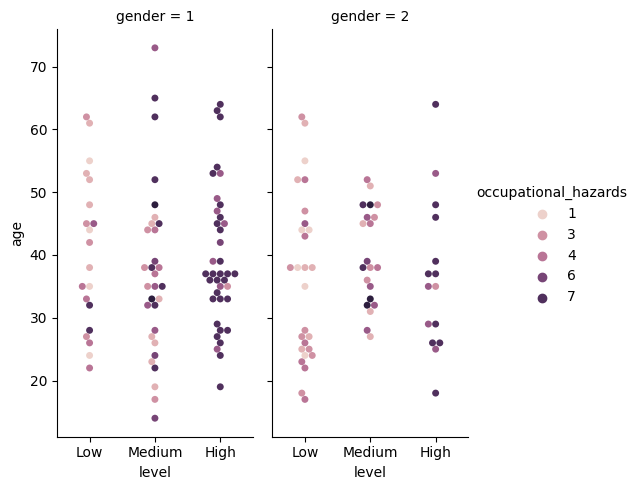

In [6]:
sns.catplot(
    data=data, kind="swarm",
    x="level", y="age", hue="occupational_hazards", col="gender",
    aspect=.5
)
data.groupby(by=["gender","level","occupational_hazards"]).size()

### Columnas de sintomas

dust_allergy
genetic_risk
chronic_lung_disease
chest_pain
coughing_of_blood
fatigue
weight_loss
shortness_of_breath
wheezing
swallowing_difficulty
clubbing_of_finger_nails
frequent_cold
dry_cough
snoring


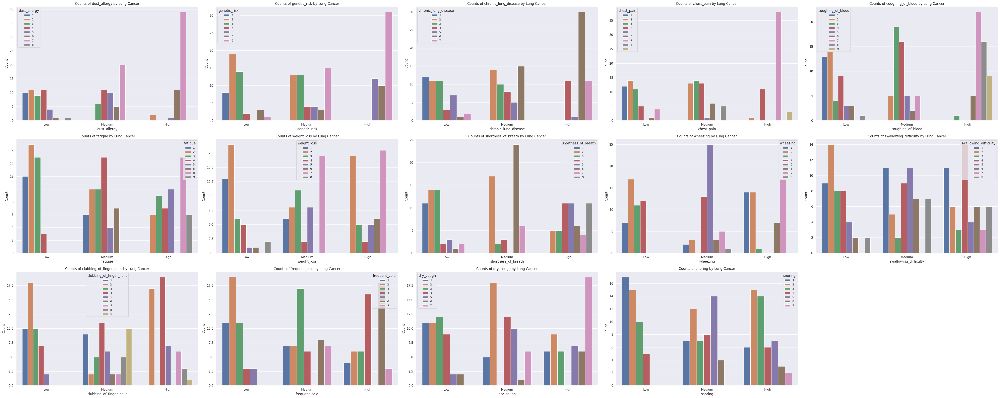

In [ ]:
data_copy = data.copy()
health_factors = ['dust_allergy','genetic_risk','chronic_lung_disease','chest_pain','coughing_of_blood', 'fatigue', 'weight_loss', 'shortness_of_breath', 'wheezing', 'swallowing_difficulty', 'clubbing_of_finger_nails', 'frequent_cold', 'dry_cough', 'snoring']
plt.figure(figsize=(50, 20))
for i, factor in enumerate(health_factors):
    plt.subplot(3, 5, i + 1)
    data_copy[factor] = data_copy[factor].map({'Low': 'Low', 'Medium': 'Medium', 'High': 'High'})
    print(factor)
    ax = sns.countplot(data=data_copy, x=data['level'], hue=data[factor])
    plt.title(f'Counts of {factor} by Lung Cancer')
    plt.xlabel(factor)
    plt.ylabel('Count')
    total_count = len(data_copy)

sns.set(rc={'legend.fontsize': 10})
plt.tight_layout()
plt.show()

In [ ]:
'chest_pain','coughing_of_blood', 'fatigue', 'weight_loss', 'shortness_of_breath', 'wheezing', 'swallowing_difficulty', 'clubbing_of_finger_nails', 'frequent_cold', 'dry_cough', 'snoring'

In [ ]:
data_copy = data.copy()

In [ ]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(data_copy['dust_allergy'] + data_copy['chronic_lung_disease'] + data_copy['genetic_risk'] + data_copy['chest_pain'] + data_copy['coughing_of_blood'] + data_copy['fatigue'] + data_copy['weight_loss'] + data_copy['shortness_of_breath'] + data_copy['wheezing'] + data_copy['swallowing_difficulty'] + data_copy['clubbing_of_finger_nails'] + data_copy['frequent_cold']+ data_copy['dry_cough']+ data_copy['snoring'], data_copy['level'])
chi2, p, _, _ = chi2_contingency(contingency_table)
alpha = 0.05
if p < alpha:
    print("There is a significant relationship between health factors and lung cancer.")
else:
    print("There is no significant relationship between health factors and lung cancer.")

There is a significant relationship between health factors and lung cancer.


## **Conclusiones sobre la Correlación Numérica, Variables y Target**

Los factores de más riesgo son:

- Toser sangre.
- Obesidad.
- Dieta Balanceada.
- Fumador Pasivo.
- Contaminación del aire.
- Consumo del alcohol.
- Dolor en el pecho.
- Peligro por género (Tal vez por el desbalance)

## Algunas Conclusiones Extra
* Sobre como influyen ciertos tipos de habitos en las personas para padecer cancer de pulmon
* Sobre como influyen ciertos sintomas medicos en las personas para padecer cancer de pulmon
* Sobre como influye el ambiente en las personas para padecer cancer de pulmon

1. Sobre fumar,beber alcohol,tener obesidad y ser fumador pasivo: balanced_diet
  * Las personas con un mayor riesgo de padecer cancer de pulmon, generalmente respondieron que fuman regularmente.
  * Hay más hombres que tienen riesgo alto de padecer cancer y fuman frecuentemente que mujeres (28 a 10).
  * La cantidad personas que consumen bebidas alcoholicas en mayor medida son aquellas que presentan un nivel de riesgo medio o alto de padecer cancer de pulmon.
  * La cantidad de hombres que toman bebidas alcoholicas frecuentemente y presentan un medio o alto riesgo de padecer cancer es mayor al numero de mujeres con las mismas condiciones.
  * Las personas con un mayor riesgo de padecer cancer de pulmon, generalmente tienen un mayor nivel de obesidad.
  * Hay mas hombres obesos con un alto riesgo de padecer cancer de pulmon que mujeres con las mismas condiciones.
  * Las personas con un mayor riesgo de padecer cancer de pulmon, generalmente son fumadores pasivos

2. Sobre los sintomas medicos:
  * La mayoria de personas que padecen estos sintomas presentan tambien cancer de pulmon.
3. Sobre el ambiente (contaminacion en el aire y exposicion a contaminantes):
  * En ambientes con contaminacion medio o alta se presentan mas casos de riesgo alto de padecer cancer de pulmon
  * En ambientes con riesgo ocupacional alta se presentan mas casos de riesgo alto y medio de padecer cancer de pulmon
4. Sobre el dataset en general:
  * Todos los datos son categoricos (22) excepto la edad que es continua.
  * No hay valores nulos ni unicos.
  * Hay 848 valores duplicados.
  * La edad maxima y minima, es 73 y 14.
  * La edad se ajusta mas a una distribucion gamma siendo la segunda mejor la distrubucion beta y normal
  * No hay outliers en la edad, sin embargo, 73 podria considerarse una.
  * La mitad de las personas del dataset son de edades entre 28 y 46 años.
  * Sobre la matriz de correlacion, respecto a la variable objetivo; todas las demas variables son independientes a excepcion de index y patient id.
  * Hay una ligera diferencia entre los 3 riesgos de padecer cancer de pulmon.

In [ ]:
'air_pollution',
'occupational_hazards'

In [ ]:
'alcohol_use','balanced_diet',
 'obesity','smoking',
 'passive_smoker',

In [ ]:
'dust_allergy',
'chest_pain',
 'coughing_of_blood',
 'fatigue',
 'weight_loss',
 'shortness_of_breath',
 'wheezing',
 'swallowing_difficulty',
 'clubbing_of_finger_nails',
 'frequent_cold',
 'dry_cough',
 'snoring',
 'genetic_risk',
 'chronic_lung_disease'

# **Modelamiento, Entrenamiento, Validación, Testing**

## **Balanceamiento ROS**




In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
X = data.drop('level', axis = 1)
Y = data['level']

In [ ]:
X.head()

,age,gender,air_pollution,alcohol_use,dust_allergy,occupational_hazards,genetic_risk,chronic_lung_disease,balanced_diet,obesity,...,coughing_of_blood,fatigue,weight_loss,shortness_of_breath,wheezing,swallowing_difficulty,clubbing_of_finger_nails,frequent_cold,dry_cough,snoring
0,33,1,2,4,5,4,3,2,2,4,...,4,3,4,2,2,3,1,2,3,4
1,17,1,3,1,5,3,4,2,2,2,...,3,1,3,7,8,6,2,1,7,2
2,35,1,4,5,6,5,5,4,6,7,...,8,8,7,9,2,1,4,6,7,2
3,37,1,7,7,7,7,6,7,7,7,...,8,4,2,3,1,4,5,6,7,5
4,46,1,6,8,7,7,7,6,7,7,...,9,3,2,4,1,4,2,4,2,3


In [ ]:
Y.head()

0       Low
1    Medium
2      High
3      High
4      High
Name: Level, dtype: object

In [ ]:
ros = RandomOverSampler(sampling_strategy='minority')
smote = SMOTE(sampling_strategy='minority')
X_resampled, Y_resampled = ros.fit_resample(X, Y)
#X_resampled, Y_resampled = smote.fit_resample(X, Y)
print("Counter:", Counter(Y_resampled))

Counter: Counter({'Low': 53, 'High': 53, 'Medium': 52})


In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier
from numpy import mean, std
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283835 sha256=99d7876689f4b736234ab4283c41b91f4f55e6ea3b171a2c34e664405b887150
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


## **SVC**

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {'C': [1, 10, 100], 'gamma' : [1, 0.1, 0.001], 'kernel' : ['linear', 'rbf']}
svc_cv = GridSearchCV(estimator=SVC(probability=True), param_grid=grid, cv= 5,scoring = ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'],refit='accuracy',)
svc_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=SVC(probability=True),
             param_grid={'C': [1, 10, 100], 'gamma': [1, 0.1, 0.001],
                         'kernel': ['linear', 'rbf']},
             refit='accuracy',
             scoring=['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted',
                      'recall_micro', 'recall_macro', 'recall_weighted',
                      'precision_micro', 'precision_macro',
                      'precision_weighted'])

In [ ]:
svc_cv.best_params_

{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}

In [ ]:
svc_cv.cv_results_

{'mean_fit_time': array([0.01714511, 0.03234038, 0.02170053, 0.02473292, 0.01509843,
        0.01494012, 0.01290188, 0.02497902, 0.01348429, 0.01614542,
        0.00725656, 0.00724978, 0.00862226, 0.01161103, 0.00938873,
        0.0101439 , 0.0074553 , 0.0070611 ]),
 'std_fit_time': array([0.00543202, 0.0153728 , 0.00786049, 0.00854848, 0.00483999,
        0.00294485, 0.001518  , 0.00623803, 0.00165627, 0.0105677 ,
        0.00050429, 0.00051872, 0.00065941, 0.00050137, 0.00312017,
        0.00023648, 0.00082343, 0.00042292]),
 'mean_score_time': array([0.02762341, 0.04012766, 0.05448923, 0.05793676, 0.0374114 ,
        0.03124127, 0.02541313, 0.02741389, 0.0298779 , 0.01605749,
        0.01519642, 0.01440368, 0.01544399, 0.01544495, 0.01609235,
        0.01447558, 0.01556597, 0.01401997]),
 'std_score_time': array([0.00300206, 0.02242392, 0.02611976, 0.02369321, 0.01072142,
        0.0074955 , 0.00249402, 0.0014726 , 0.00285186, 0.00259959,
        0.00226263, 0.00088411, 0.00135452, 

#### Test And Metrics

In [ ]:
def get_metrics(model, scoring):
  scores = []
  for score in scoring:
    idx = np.where(model.cv_results_['rank_test_'+score] == 1)
    scores = scores + [{('best_test_'+score):model.cv_results_['mean_test_'+score][idx].max()},
                       {('best_test_'+score+'_std'):model.cv_results_['std_test_'+score][idx].max()}]
  return scores

In [ ]:
svc_scores = get_metrics(svc_cv, ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'])
svc_scores

[{'best_test_accuracy': 0.9875},
 {'best_test_accuracy_std': 0.024999999999999998},
 {'best_test_f1_micro': 0.9875},
 {'best_test_f1_micro_std': 0.024999999999999998},
 {'best_test_f1_macro': 0.9872601794340925},
 {'best_test_f1_macro_std': 0.025479641131815046},
 {'best_test_f1_weighted': 0.9874870600414078},
 {'best_test_f1_weighted_std': 0.02502587991718426},
 {'best_test_recall_micro': 0.9875},
 {'best_test_recall_micro_std': 0.024999999999999998},
 {'best_test_recall_macro': 0.9872727272727273},
 {'best_test_recall_macro_std': 0.025454545454545438},
 {'best_test_recall_weighted': 0.9875},
 {'best_test_recall_weighted_std': 0.024999999999999998},
 {'best_test_precision_micro': 0.9875},
 {'best_test_precision_micro_std': 0.024999999999999998},
 {'best_test_precision_macro': 0.9877777777777776},
 {'best_test_precision_macro_std': 0.02444444444444449},
 {'best_test_precision_weighted': 0.9880208333333332},
 {'best_test_precision_weighted_std': 0.02395833333333335}]

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["High","Low","Medium"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", svc_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], svc_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  ['Medium']
Actual :      Medium


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


## **Regresión Logística**

#### Cross Validation k5 and GridSearch

In [ ]:
grid = { 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
        'penalty':['l2'],
         'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000] }
lr_cv = GridSearchCV(estimator=LogisticRegression(max_iter = 5000), param_grid=grid, cv= 5,scoring = ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'],refit='accuracy',)
lr_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l2'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             refit='accuracy',
             scoring=['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted',
                      'recall_micro', 'recall_macro', 'recall_weighted',
                      'precision_micro', 'precision_macro',
                      'precision_weighted'])

In [ ]:
lr_cv.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}

In [ ]:
lr_cv.cv_results_

{'mean_fit_time': array([0.02208633, 0.01849904, 0.00331869, 0.0974194 , 0.13412199,
        0.02648454, 0.03382063, 0.003584  , 0.1726965 , 0.20116081,
        0.03608484, 0.08068986, 0.0038763 , 0.28199182, 0.05565381,
        0.07702274, 0.17053952, 0.00438728, 0.10452046, 0.2735496 ,
        0.10783725, 0.38052926, 0.00553937, 0.20110302, 0.27503099,
        0.07307668, 0.27511954, 0.00660863, 0.24610415, 0.30221047,
        0.0768167 , 0.26820226, 0.00838933, 0.41740685, 0.42818799]),
 'std_fit_time': array([7.58530140e-03, 3.94342065e-03, 2.22162398e-04, 6.04608242e-03,
        2.84457936e-02, 8.84183488e-04, 5.49905550e-03, 4.62378609e-04,
        1.22192730e-02, 2.39707682e-02, 4.33451351e-03, 9.81507965e-03,
        1.90917857e-04, 1.99636194e-02, 5.16231719e-03, 3.15447180e-02,
        1.46760144e-02, 9.07822814e-05, 9.89194643e-03, 2.98100150e-02,
        8.81026185e-03, 1.17784190e-01, 3.52936150e-04, 2.74343722e-02,
        3.75578728e-02, 1.04487437e-02, 7.35751031e-02, 5

#### Test And Metrics

In [ ]:
lr_scores = get_metrics(lr_cv, ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'])
lr_scores

[{'best_test_accuracy': 0.98125},
 {'best_test_accuracy_std': 0.037500000000000006},
 {'best_test_f1_micro': 0.98125},
 {'best_test_f1_micro_std': 0.037500000000000006},
 {'best_test_f1_macro': 0.9807780320366133},
 {'best_test_f1_macro_std': 0.03844393592677346},
 {'best_test_f1_weighted': 0.9811641876430206},
 {'best_test_f1_weighted_std': 0.037671624713958796},
 {'best_test_recall_micro': 0.98125},
 {'best_test_recall_micro_std': 0.037500000000000006},
 {'best_test_recall_macro': 0.9806060606060605},
 {'best_test_recall_macro_std': 0.038787878787878816},
 {'best_test_recall_weighted': 0.98125},
 {'best_test_recall_weighted_std': 0.037500000000000006},
 {'best_test_precision_micro': 0.98125},
 {'best_test_precision_micro_std': 0.037500000000000006},
 {'best_test_precision_macro': 0.9814814814814815},
 {'best_test_precision_macro_std': 0.03703703703703702},
 {'best_test_precision_weighted': 0.9815972222222221},
 {'best_test_precision_weighted_std': 0.036805555555555536}]

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["High","Low","Medium"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", lr_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], lr_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  ['High']
Actual :      High


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## **Árbol de Decisión**

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'ccp_alpha': [0.1, 0.01, 0.001],
    'max_depth': [8, 9, 10, 11, 12],
    'criterion': ['gini', 'entropy']
}
dt_cv = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted']
                     ,refit='accuracy')
dt_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'ccp_alpha': [0.1, 0.01, 0.001],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [8, 9, 10, 11, 12]},
             refit='accuracy',
             scoring=['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted',
                      'recall_micro', 'recall_macro', 'recall_weighted',
                      'precision_micro', 'precision_macro',
                      'precision_weighted'])

In [ ]:
dt_cv.best_params_

{'ccp_alpha': 0.01, 'criterion': 'entropy', 'max_depth': 8}

In [ ]:
dt_cv.cv_results_

{'mean_fit_time': array([0.0052701 , 0.00425   , 0.00358505, 0.0037889 , 0.00327425,
        0.00287094, 0.00288506, 0.00321822, 0.00311375, 0.00280194,
        0.00272188, 0.00276055, 0.00308504, 0.00298162, 0.00294328,
        0.0035759 , 0.00323339, 0.00285978, 0.00317798, 0.00525947,
        0.00453749, 0.00435972, 0.00445538, 0.00644331, 0.00461049,
        0.00495906, 0.00706844, 0.00515752, 0.00679173, 0.00652299]),
 'std_fit_time': array([2.73950913e-03, 5.91421329e-04, 7.21331704e-04, 6.88499844e-04,
        9.50261583e-04, 1.11025734e-04, 1.95777189e-04, 6.03088312e-04,
        4.44131054e-04, 5.78750285e-05, 6.99591129e-05, 2.04945787e-04,
        7.68612580e-04, 3.77338342e-04, 3.38454131e-04, 6.62398877e-04,
        5.02366954e-04, 8.43382463e-05, 6.38914188e-04, 8.71936641e-04,
        2.73749783e-04, 8.02451911e-05, 6.59414932e-05, 4.10939273e-03,
        5.24510696e-04, 9.22959349e-04, 4.90994485e-03, 1.32307563e-03,
        2.67054316e-03, 3.70428660e-03]),
 'mean_scor

#### Test And Metrics

In [ ]:
dt_scores = get_metrics(dt_cv, ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'])
dt_scores

[{'best_test_accuracy': 0.975},
 {'best_test_accuracy_std': 0.03644344934278313},
 {'best_test_f1_micro': 0.975},
 {'best_test_f1_micro_std': 0.03644344934278313},
 {'best_test_f1_macro': 0.9747619047619047},
 {'best_test_f1_macro_std': 0.036722626163726305},
 {'best_test_f1_weighted': 0.9748958333333334},
 {'best_test_f1_weighted_std': 0.03664002346402693},
 {'best_test_recall_micro': 0.975},
 {'best_test_recall_micro_std': 0.03644344934278313},
 {'best_test_recall_macro': 0.9751515151515152},
 {'best_test_recall_macro_std': 0.0364846471352543},
 {'best_test_recall_weighted': 0.975},
 {'best_test_recall_weighted_std': 0.03644344934278313},
 {'best_test_precision_micro': 0.975},
 {'best_test_precision_micro_std': 0.03644344934278313},
 {'best_test_precision_macro': 0.9770163170163169},
 {'best_test_precision_macro_std': 0.03297510740447603},
 {'best_test_precision_weighted': 0.9774912587412586},
 {'best_test_precision_weighted_std': 0.032718474252120475}]

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["High","Low","Medium"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", dt_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], dt_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  ['Medium']
Actual :      Medium


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## **Random Forest**

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'n_estimators':[10,100,200],
    'max_features':['sqrt', 'log2', None],
    'min_samples_leaf':[1,2,3],
    'min_samples_split':[2,3,4,5],
    }
rf_cv = GridSearchCV(estimator=RandomForestClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted']
                     ,refit='accuracy')
rf_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [10, 100, 200]},
             refit='accuracy',
             scoring=['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted',
                      'recall_micro', 'recall_macro', 'recall_weighted',
                      'precision_micro', 'precision_macro',
                      'precision_weighted'])

In [ ]:
rf_cv.best_params_

{'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [ ]:
rf_cv.cv_results_

{'mean_fit_time': array([0.02103834, 0.15405364, 0.29545984, 0.01764479, 0.14965682,
        0.28920617, 0.01747136, 0.1508832 , 0.28924651, 0.01760583,
        0.1472528 , 0.45437646, 0.05690446, 0.42096872, 0.44522214,
        0.01687222, 0.20469575, 0.4830883 , 0.01728258, 0.14552388,
        0.29440222, 0.01760039, 0.18409214, 0.46099105, 0.02703872,
        0.1673964 , 0.29412055, 0.01780005, 0.14516177, 0.29302549,
        0.01725712, 0.15122929, 0.47285175, 0.02988105, 0.31176543,
        0.51816196, 0.06254172, 0.33829575, 0.66277089, 0.03174858,
        0.25781317, 0.5360589 , 0.04503903, 0.48278995, 0.56610775,
        0.01756988, 0.14893179, 0.47493811, 0.02959251, 0.28698759,
        0.8165834 , 0.09249625, 0.39197607, 0.50934906, 0.0374475 ,
        0.36142764, 0.37575336, 0.01745734, 0.15239496, 0.62575717,
        0.02845969, 0.17254367, 0.29778719, 0.01851797, 0.24246974,
        0.73514171, 0.03532491, 0.24729767, 0.43219924, 0.02991996,
        0.22696695, 0.29060626,

#### Test And Metrics

In [ ]:
rf_scores = get_metrics(rf_cv, ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'])
rf_scores

[{'best_test_accuracy': 0.9875},
 {'best_test_accuracy_std': 0.015309310892394862},
 {'best_test_f1_micro': 0.9875},
 {'best_test_f1_micro_std': 0.015309310892394862},
 {'best_test_f1_macro': 0.9875776397515528},
 {'best_test_f1_macro_std': 0.015220481713833235},
 {'best_test_f1_weighted': 0.9875},
 {'best_test_f1_weighted_std': 0.015309310892394862},
 {'best_test_recall_micro': 0.9875},
 {'best_test_recall_micro_std': 0.015309310892394862},
 {'best_test_recall_macro': 0.9878787878787879},
 {'best_test_recall_macro_std': 0.014845392380504096},
 {'best_test_recall_weighted': 0.9875},
 {'best_test_recall_weighted_std': 0.015309310892394862},
 {'best_test_precision_micro': 0.9875},
 {'best_test_precision_micro_std': 0.015309310892394862},
 {'best_test_precision_macro': 0.9883838383838384},
 {'best_test_precision_macro_std': 0.014249228262288768},
 {'best_test_precision_weighted': 0.9886363636363636},
 {'best_test_precision_weighted_std': 0.013917555356722618}]

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["High","Low","Medium"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", rf_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], rf_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Prediction :  ['Low']
Actual :      Low


## **XGBoost**

#### Cross Validation k5 and GridSearch

In [ ]:
Y_resampled

0         Low
1      Medium
2        High
3        High
4        High
        ...  
153       Low
154       Low
155       Low
156       Low
157       Low
Name: level, Length: 158, dtype: object

In [ ]:
Y_resampled_1 = Y_resampled.map({'Low': 0, 'Medium': 1, 'High': 2})

In [ ]:
Y_resampled_1

0      0
1      1
2      2
3      2
4      2
      ..
153    0
154    0
155    0
156    0
157    0
Name: level, Length: 158, dtype: int64

In [ ]:
grid = {
    'max_depth': range (2, 10, 1),
    'n_estimators': range(60, 220, 40),
    'learning_rate': [0.1, 0.01, 0.05]
  }
xgb_cv = GridSearchCV(estimator=XGBClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted']
                      ,refit='accuracy')
xgb_cv.fit(X_resampled, Y_resampled_1)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.05],
                         'max_depth': range(2, 10),
                         'n_estimators': range(60, 220, 40)},
             refit='accuracy',
             scoring=['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted',
                      'recall_micro', 'recall_macro', 'recall_weighted',
                      'precision_micro', 'precision_macro',
                      'precision_weighted'])

In [ ]:
xgb_cv.best_params_

{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 60}

In [ ]:
xgb_cv.cv_results_

{'mean_fit_time': array([0.13312063, 0.0746738 , 0.06768064, 0.08366737, 0.04117856,
        0.05497251, 0.06798701, 0.08138185, 0.04200878, 0.05585532,
        0.06926484, 0.08846054, 0.04103174, 0.05927963, 0.07036052,
        0.08375349, 0.04300904, 0.05721588, 0.07180934, 0.08058395,
        0.04758873, 0.05591621, 0.0684979 , 0.08547573, 0.1066648 ,
        0.31956534, 0.13999515, 0.08626618, 0.04179711, 0.05738535,
        0.07263145, 0.08203211, 0.03882957, 0.05321693, 0.07219739,
        0.09030476, 0.04269991, 0.06327224, 0.08163052, 0.10808702,
        0.04513621, 0.07115335, 0.09251523, 0.11871557, 0.0474937 ,
        0.2806982 , 0.43618889, 0.19491315, 0.04757195, 0.07782555,
        0.0975965 , 0.12091818, 0.05689526, 0.13510461, 0.09545798,
        0.11907477, 0.04774575, 0.07193551, 0.10065866, 0.12283397,
        0.04881616, 0.07637639, 0.09642091, 0.1263907 , 0.03581557,
        0.10263672, 0.38884845, 0.14104009, 0.04106603, 0.05859017,
        0.07744966, 0.09089665,

#### Test And Metrics

In [ ]:
xgb_scores = get_metrics(xgb_cv, ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'])
xgb_scores

[{'best_test_accuracy': 0.99375},
 {'best_test_accuracy_std': 0.012499999999999999},
 {'best_test_f1_micro': 0.99375},
 {'best_test_f1_micro_std': 0.012499999999999999},
 {'best_test_f1_macro': 0.9939268461007591},
 {'best_test_f1_macro_std': 0.012146307798481713},
 {'best_test_f1_weighted': 0.9937370600414079},
 {'best_test_f1_weighted_std': 0.012525879917184303},
 {'best_test_recall_micro': 0.99375},
 {'best_test_recall_micro_std': 0.012499999999999999},
 {'best_test_recall_macro': 0.9939393939393939},
 {'best_test_recall_macro_std': 0.01212121212121211},
 {'best_test_recall_weighted': 0.99375},
 {'best_test_recall_weighted_std': 0.012499999999999999},
 {'best_test_precision_micro': 0.99375},
 {'best_test_precision_micro_std': 0.012499999999999999},
 {'best_test_precision_macro': 0.9944444444444445},
 {'best_test_precision_macro_std': 0.011111111111111117},
 {'best_test_precision_weighted': 0.9942708333333332},
 {'best_test_precision_weighted_std': 0.011458333333333346}]

#### Lime Explanation

In [ ]:
# {'Low': 0, 'Medium': 1, 'High': 2}

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["High","Low","Medium"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", xgb_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], xgb_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  [1]
Actual :      Medium


## **SGD**

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'loss':['log_loss', 'hinge', "squared_hinge", "modified_huber"],
    'penalty':['elasticnet','l2','l1'],
    'alpha':np.logspace(-4, 4, 10),
    'l1_ratio':[0.05,0.06,0.07,0.08,0.09,0.1,0.12,0.13,0.14,0.15,0.2]
    }
sgd_cv = GridSearchCV(estimator=SGDClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted']
                      ,refit='accuracy')
sgd_cv.fit(X_resampled, Y_resampled_1)

Se han truncado las últimas 5000 líneas del flujo de salida.
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sk

GridSearchCV(cv=5, estimator=SGDClassifier(),
             param_grid={'alpha': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                         'l1_ratio': [0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12,
                                      0.13, 0.14, 0.15, 0.2],
                         'loss': ['log_loss', 'hinge', 'squared_hinge',
                                  'modified_huber'],
                         'penalty': ['elasticnet', 'l2', 'l1']},
             refit='accuracy',
             scoring=['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted',
                      'recall_micro', 'recall_macro', 'recall_weighted',
                      'precision_micro', 'precision_macro',
                      'precision_weighted'])

In [ ]:
sgd_cv.best_params_

{'alpha': 2.782559402207126,
 'l1_ratio': 0.06,
 'loss': 'squared_hinge',
 'penalty': 'l2'}

In [ ]:
grid = {
    'loss':["squared_hinge"],
    'penalty':['l2'],
    'alpha':[0.33,0.34,0.35,0.36,0.37,0.38],
    'l1_ratio':[0.01,0.03,0.04,0.05,0.06,0.07]
    }
sgd_cv = GridSearchCV(estimator=SGDClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted']
                      ,refit='accuracy')
sgd_cv.fit(X_resampled, Y_resampled_1)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning

GridSearchCV(cv=5, estimator=SGDClassifier(),
             param_grid={'alpha': [0.33, 0.34, 0.35, 0.36, 0.37, 0.38],
                         'l1_ratio': [0.01, 0.03, 0.04, 0.05, 0.06, 0.07],
                         'loss': ['squared_hinge'], 'penalty': ['l2']},
             refit='accuracy',
             scoring=['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted',
                      'recall_micro', 'recall_macro', 'recall_weighted',
                      'precision_micro', 'precision_macro',
                      'precision_weighted'])

In [ ]:
sgd_cv.best_params_

{'alpha': 0.38, 'l1_ratio': 0.05, 'loss': 'squared_hinge', 'penalty': 'l2'}

In [ ]:
sgd_cv.cv_results_

{'mean_fit_time': array([0.0144773 , 0.01740103, 0.01799273, 0.01368217, 0.01569953,
        0.01267824, 0.01554508, 0.00823112, 0.00790119, 0.00816393,
        0.00796533, 0.00846682, 0.00831308, 0.00810008, 0.00791254,
        0.00553064, 0.00498562, 0.00478935, 0.00483308, 0.00488491,
        0.00520835, 0.00470543, 0.00545683, 0.00532398, 0.00509663,
        0.00467701, 0.00470738, 0.00491428, 0.00489054, 0.00478673,
        0.00551691, 0.00473185, 0.00496225, 0.00542774, 0.00549316,
        0.00501618]),
 'std_fit_time': array([0.00397677, 0.00497352, 0.00222904, 0.00795376, 0.00464946,
        0.0046887 , 0.00727998, 0.00098785, 0.00075613, 0.00114688,
        0.00086061, 0.00112108, 0.00129268, 0.00111153, 0.00029818,
        0.0010954 , 0.0005734 , 0.00019255, 0.00017982, 0.00022699,
        0.00088613, 0.00014062, 0.00104817, 0.00090741, 0.00052627,
        0.0002071 , 0.00018265, 0.00020463, 0.00016136, 0.0002616 ,
        0.00084505, 0.00012216, 0.00035896, 0.00076708, 0.001

#### Test And Metrics

In [ ]:
sgd_scores = get_metrics(sgd_cv, ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'])
sgd_scores

[{'best_test_accuracy': 0.9304435483870968},
 {'best_test_accuracy_std': 0.053917789194989615},
 {'best_test_f1_micro': 0.9304435483870968},
 {'best_test_f1_micro_std': 0.053917789194989615},
 {'best_test_f1_macro': 0.9292806346124424},
 {'best_test_f1_macro_std': 0.05581416794910748},
 {'best_test_f1_weighted': 0.9294450493011291},
 {'best_test_f1_weighted_std': 0.05531577079188905},
 {'best_test_recall_micro': 0.9304435483870968},
 {'best_test_recall_micro_std': 0.053917789194989615},
 {'best_test_recall_macro': 0.9303030303030303},
 {'best_test_recall_macro_std': 0.054981422691111406},
 {'best_test_recall_weighted': 0.9304435483870968},
 {'best_test_recall_weighted_std': 0.053917789194989615},
 {'best_test_precision_micro': 0.9304435483870968},
 {'best_test_precision_micro_std': 0.053917789194989615},
 {'best_test_precision_macro': 0.9348445998445998},
 {'best_test_precision_macro_std': 0.05312663819444016},
 {'best_test_precision_weighted': 0.9349304693961951},
 {'best_test_precisi

#### Lime Explanation

In [ ]:
# {'Low': 0, 'Medium': 1, 'High': 2}

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="regression", class_names=["level"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", sgd_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])
#https://stackoverflow.com/questions/55250963/how-to-get-probabilities-for-sgdclassifier-linearsvm
explanation = explainer.explain_instance(X_resampled.values[idx], sgd_cv.best_estimator_.predict, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  [1]
Actual :      Medium


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


## ANN

#### Initializing the ANN

In [ ]:
!pip install scikeras[tensorflow]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 17.8 MB/s eta 0:00:00
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.15.0
    Uninstalling tensorflow-estimator-2.15.0:
      Successfully uninstalled tensorflow-estimator-2.15.0
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
  Attempting uninstall: gast
    Found existing installation: gast 0.5.4
    Uninstalling gast-0.5.4:
      Successfully uninstalled gast-0.5.4
  Attempting uninstall: google-auth-oauthlib
    Found existing installation: google-auth-oauthlib 1.2.0
    Uninstalling google-auth-oauthlib-1.2.0:
      Successfully un

In [ ]:
import tensorflow as tf
import keras
from keras import layers
from sklearn.preprocessing import StandardScaler

In [ ]:
from scikeras.wrappers import KerasClassifier

In [ ]:
y = pd.get_dummies(Y_resampled)
y

,High,Low,Medium
0,0,1,0
1,0,0,1
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
153,0,1,0
154,0,1,0
155,0,1,0
156,0,1,0


In [ ]:
def FunctionFindBestParams(X_train, y_train):

    # Defining the list of hyper parameters to try
    TrialNumber=0
    batch_size_list=[5, 10, 15, 20]
    epoch_list=[5, 10, 50 ,100]
    optimizers=['rmsprop','adam']

    import pandas as pd
    SearchResultsData=pd.DataFrame(columns=['TrialNumber', 'Parameters', 'Accuracy'])

    for batch_size_trial in batch_size_list:
        for epochs_trial in epoch_list:
          for optimizer_ in optimizers:
              TrialNumber+=1

              # Creating the classifier ANN model
              model = keras.Sequential([
                keras.layers.Dense(8, input_dim=23, activation='relu'),
                keras.layers.Dense(16,activation='relu'),
                keras.layers.Dropout(0.1),
                keras.layers.Dense(8,activation='relu'),
                keras.layers.Dense(3,activation='softmax'),
              ])
              model.compile(
                optimizer=optimizer_,
                loss='categorical_crossentropy',
                metrics=['accuracy'],
              )
              history = model.fit(X_train, y_train,
                      batch_size=batch_size_trial ,
                      epochs=epochs_trial,
                      verbose=0,)

    # Fetching the accuracy of the training
              Accuracy = history.history['accuracy'][-1]

              # printing the results of the current iteration
              print(TrialNumber, 'Parameters:',' batch_size:', batch_size_trial,' - ', 'epochs:',epochs_trial,' - ', 'optimizer:',optimizer_,' - ', 'Accuracy:', Accuracy)

              SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,
                              'batch_size '+str(batch_size_trial)+'-'+'optimizer '+str(optimizer_)+'-'+'epoch '+str(epochs_trial), Accuracy]],
                                                                      columns=['TrialNumber', 'Parameters', 'Accuracy'] ))
    return(SearchResultsData)

###############################################

# Calling the function
ResultsData=FunctionFindBestParams(X_resampled, y)

1 Parameters:  batch_size: 5  -  epochs: 5  -  optimizer: rmsprop  -  Accuracy: 0.5696202516555786


<ipython-input-94-9d67cb3ca6eb>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


2 Parameters:  batch_size: 5  -  epochs: 5  -  optimizer: adam  -  Accuracy: 0.474683552980423


<ipython-input-94-9d67cb3ca6eb>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


3 Parameters:  batch_size: 5  -  epochs: 10  -  optimizer: rmsprop  -  Accuracy: 0.6518987417221069


...

<ipython-input-94-9d67cb3ca6eb>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


31 Parameters:  batch_size: 20  -  epochs: 100  -  optimizer: rmsprop  -  Accuracy: 0.8291139006614685


<ipython-input-94-9d67cb3ca6eb>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


32 Parameters:  batch_size: 20  -  epochs: 100  -  optimizer: adam  -  Accuracy: 0.9113923907279968


<ipython-input-94-9d67cb3ca6eb>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


In [ ]:
# Printing the best parameter
print(ResultsData.sort_values(by='Accuracy', ascending=False).head(1))

  TrialNumber                              Parameters  Accuracy
0          16  batch_size 10-optimizer adam-epoch 100  0.974684


#### Test And Metrics

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
# from keras.wrappers.scikit_learn import KerasClassifier
import keras.engine

def build_model():
    model = keras.Sequential([
      keras.layers.Dense(8, input_dim=23, activation='relu'),
      keras.layers.Dense(16,activation='relu'),
      keras.layers.Dropout(0.1),
      keras.layers.Dense(8,activation='relu'),
      keras.layers.Dense(3,activation='softmax'),
    ])
    model.compile(
      optimizer='adam',
      loss='categorical_crossentropy',
      metrics=['accuracy'],
    )
    return model

model = build_model()

# X_train = StandardScaler().fit_transform(X_resampled)

In [ ]:
def get_metrics_cv(cv_results, scoring):
  scores = []
  for score in scoring:
    sc = cv_results['test_'+score].mean()
    scores = scores + [{('best_test_'+score):sc},
                       {('best_test_'+score+'_std'):(float(1)-sc)}]
  return scores

In [ ]:
keras_clf = KerasClassifier(build_model,target_type_='multiclass', epochs=100, batch_size=10, verbose=1)

cv_results = cross_validate(estimator = keras_clf, scoring = ['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'],
    X=X_resampled, y=y, cv=5)

Epoch 1/100
13/13 [==============================] - 5s 5ms/step - loss: 3.0671 - accuracy: 0.3016
Epoch 2/100
13/13 [==============================] - 0s 4ms/step - loss: 1.8933 - accuracy: 0.2778
Epoch 3/100
13/13 [==============================] - 0s 4ms/step - loss: 1.6535 - accuracy: 0.2540
Epoch 4/100
13/13 [==============================] - 0s 4ms/step - loss: 1.3432 - accuracy: 0.3333
Epoch 5/100
13/13 [==============================] - 0s 5ms/step - loss: 1.2542 - accuracy: 0.3730
Epoch 6/100
13/13 [==============================] - 0s 4ms/step - loss: 1.2369 - accuracy: 0.3571
Epoch 7/100
13/13 [==============================] - 0s 7ms/step - loss: 1.2722 - accuracy: 0.3651
Epoch 8/100
13/13 [==============================] - 0s 6ms/step - loss: 1.1634 - accuracy: 0.3333
Epoch 9/100
13/13 [==============================] - 0s 5ms/step - loss: 1.1467 - accuracy: 0.3889
Epoch 10/100
13/13 [==============================] - 0s 3ms/step - loss: 1.1113 - accuracy: 0.3730
Epoch 11/

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


13/13 [==============================] - 1s 4ms/step - loss: 1.8968 - accuracy: 0.4206
Epoch 2/100
13/13 [==============================] - 0s 5ms/step - loss: 1.4302 - accuracy: 0.4444
Epoch 3/100
13/13 [==============================] - 0s 4ms/step - loss: 1.1418 - accuracy: 0.3968
Epoch 4/100
13/13 [==============================] - 0s 4ms/step - loss: 1.0554 - accuracy: 0.4841
Epoch 5/100
13/13 [==============================] - 0s 4ms/step - loss: 1.0424 - accuracy: 0.4683
Epoch 6/100
13/13 [==============================] - 0s 4ms/step - loss: 1.0231 - accuracy: 0.4524
Epoch 7/100
13/13 [==============================] - 0s 4ms/step - loss: 1.0058 - accuracy: 0.4365
Epoch 8/100
13/13 [==============================] - 0s 4ms/step - loss: 0.9516 - accuracy: 0.4762
Epoch 9/100
13/13 [==============================] - 0s 3ms/step - loss: 0.9518 - accuracy: 0.4444
Epoch 10/100
13/13 [==============================] - 0s 4ms/step - loss: 0.9535 - accuracy: 0.4365
Epoch 11/100
13/13 [=

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


13/13 [==============================] - 1s 3ms/step - loss: 4.9442 - accuracy: 0.3937
Epoch 2/100
13/13 [==============================] - 0s 3ms/step - loss: 3.4332 - accuracy: 0.3937
Epoch 3/100
13/13 [==============================] - 0s 3ms/step - loss: 2.3490 - accuracy: 0.3858
Epoch 4/100
13/13 [==============================] - 0s 3ms/step - loss: 1.7589 - accuracy: 0.3701
Epoch 5/100
13/13 [==============================] - 0s 3ms/step - loss: 1.4476 - accuracy: 0.3543
Epoch 6/100
13/13 [==============================] - 0s 3ms/step - loss: 1.2538 - accuracy: 0.4173
Epoch 7/100
13/13 [==============================] - 0s 3ms/step - loss: 1.1337 - accuracy: 0.4724
Epoch 8/100
13/13 [==============================] - 0s 3ms/step - loss: 1.1529 - accuracy: 0.4646
Epoch 9/100
13/13 [==============================] - 0s 3ms/step - loss: 1.0630 - accuracy: 0.5669
Epoch 10/100
13/13 [==============================] - 0s 3ms/step - loss: 1.0852 - accuracy: 0.5748
Epoch 11/100
13/13 [=

In [ ]:
print(cv_results['test_accuracy'])
print(cv_results['test_f1_micro'])
print(cv_results['test_f1_macro'])
print(cv_results['test_f1_weighted'])
print(cv_results['test_recall_micro'])
print(cv_results['test_recall_macro'])
print(cv_results['test_recall_weighted'])
print(cv_results['test_precision_micro'])
print(cv_results['test_precision_macro'])
print(cv_results['test_precision_weighted'])

[0.59375    0.875      0.8125     0.90322581 0.93548387]
[0.59375    0.875      0.8125     0.90322581 0.93548387]
[0.51527778 0.58985507 0.54742547 0.86728395 0.92334284]
[0.56588542 0.89048913 0.86941057 0.90890084 0.9386871 ]
[0.59375    0.875      0.8125     0.90322581 0.93548387]
[0.52597403 0.60606061 0.4992785  0.92857143 0.94444444]
[0.59375    0.875      0.8125     0.90322581 0.93548387]
[0.59375    0.875      0.8125     0.90322581 0.93548387]
[0.52222222 0.58974359 0.61904762 0.84102564 0.91666667]
[0.55625    0.92788462 0.95089286 0.92655087 0.9516129 ]


In [ ]:
ann_scores = get_metrics_cv(cv_results,['accuracy', 'f1_micro', 'f1_macro', 'f1_weighted','recall_micro','recall_macro','recall_weighted', 'precision_micro', 'precision_macro', 'precision_weighted'])
ann_scores

[{'best_test_accuracy': 0.823991935483871},
 {'best_test_accuracy_std': 0.17600806451612905},
 {'best_test_f1_micro': 0.823991935483871},
 {'best_test_f1_micro_std': 0.17600806451612905},
 {'best_test_f1_macro': 0.6886370229943678},
 {'best_test_f1_macro_std': 0.3113629770056322},
 {'best_test_f1_weighted': 0.834674609693035},
 {'best_test_f1_weighted_std': 0.16532539030696503},
 {'best_test_recall_micro': 0.823991935483871},
 {'best_test_recall_micro_std': 0.17600806451612905},
 {'best_test_recall_macro': 0.7008658008658009},
 {'best_test_recall_macro_std': 0.29913419913419914},
 {'best_test_recall_weighted': 0.823991935483871},
 {'best_test_recall_weighted_std': 0.17600806451612905},
 {'best_test_precision_micro': 0.823991935483871},
 {'best_test_precision_micro_std': 0.17600806451612905},
 {'best_test_precision_macro': 0.6977411477411477},
 {'best_test_precision_macro_std': 0.3022588522588523},
 {'best_test_precision_weighted': 0.8626382488479262},
 {'best_test_precision_weighted_st

### Resumen de resultados

In [ ]:
models_scores = [svc_scores,lr_scores,dt_scores,rf_scores,xgb_scores,sgd_scores,ann_scores]
results = {
    'Modelos' : ['SVC','Regresion Logistica','Arbol de decision','Bosque Aleatorio','XGBoost','Stochastic Gradient Boost','ANN'],
    'Accuracy' : [],
    'F1-score Micro' : [],
    'F1-score Macro' : [],
    'F1-score Weighted' : [],
    'Recall Micro' : [],
    'Recall Macro' : [],
    'Recall Weighted' : [],
    'Precision Micro' : [],
    'Precision Macro' : [],
    'Precision Weighted' : [],
}
for model_score in models_scores:
  results['Accuracy'].append(model_score[0]['best_test_accuracy'])
  results['F1-score Micro'].append(model_score[2]['best_test_f1_micro'])
  results['F1-score Macro'].append(model_score[4]['best_test_f1_macro'])
  results['F1-score Weighted'].append(model_score[6]['best_test_f1_weighted'])
  results['Recall Micro'].append(model_score[8]['best_test_recall_micro'])
  results['Recall Macro'].append(model_score[10]['best_test_recall_macro'])
  results['Recall Weighted'].append(model_score[12]['best_test_recall_weighted'])
  results['Precision Micro'].append(model_score[14]['best_test_precision_micro'])
  results['Precision Macro'].append(model_score[16]['best_test_precision_macro'])
  results['Precision Weighted'].append(model_score[18]['best_test_precision_weighted'])
df_results = pd.DataFrame(results)
df_results

,Modelos,Accuracy,F1-score Micro,F1-score Macro,F1-score Weighted,Recall Micro,Recall Macro,Recall Weighted,Precision Micro,Precision Macro,Precision Weighted
0,SVC,0.987500,0.987500,0.987260,0.987487,0.987500,0.987273,0.987500,0.987500,0.987778,0.988021
1,Regresion Logistica,0.981250,0.981250,0.980778,0.981164,0.981250,0.980606,0.981250,0.981250,0.981481,0.981597
2,Arbol de decision,0.975000,0.975000,0.974762,0.974896,0.975000,0.975152,0.975000,0.975000,0.977016,0.977491
3,Bosque Aleatorio,0.987500,0.987500,0.987578,0.987500,0.987500,0.987879,0.987500,0.987500,0.988384,0.988636
4,XGBoost,0.993750,0.993750,0.993927,0.993737,0.993750,0.993939,0.993750,0.993750,0.994444,0.994271
5,Stochastic Gradient Boost,0.930444,0.930444,0.929281,0.929445,0.930444,0.930303,0.930444,0.930444,0.934845,0.934930
6,ANN,0.823992,0.823992,0.688637,0.834675,0.823992,0.700866,0.823992,0.823992,0.697741,0.862638


In [ ]:
# dominating class has better predictions and so the micro average increase